In [17]:
from aoptk.literature.databases.aop_wiki import AOPWiki

abstracts = AOPWiki().get_abstracts()


In [18]:
from aoptk.text_generation_api import TextGenerationAPI
from pathlib import Path

organ_list = [
    "Cardiovascular",
    "Dermal",
    "Development",
    "Endocrine",
    "Gastrointestinal",
    "Hematologic",
    "Hepatic",
    "Immune",
    "Musculoskeletal",
    "Nervous",
    "Ocular",
    "Other",
    "Reproductive",
    "Respiratory",
    "Urinary",
]

TextGenerationAPI().specification_categorization_prompt = Path(
    "prompt_specification.txt",
).read_text(encoding="utf-8")

results = []
for abstract in abstracts:
    abstract_id = abstract.id
    category = TextGenerationAPI().categorize_text(abstract, organ_list)
    results.append((abstract_id, abstract, category))

In [19]:
import pandas as pd

df = pd.DataFrame(results, columns=["abstract_id", "abstract", "category"])
df.to_excel("aop_organs.xlsx", index=False)

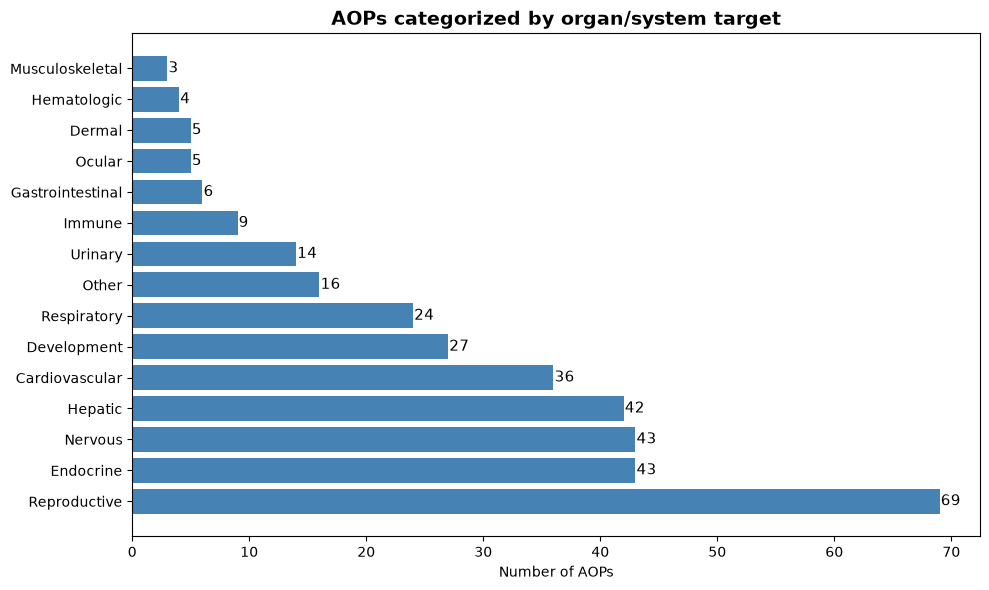

In [20]:
import matplotlib.pyplot as plt

category_counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(category_counts)), category_counts.values, color="steelblue")
ax.set_yticks(range(len(category_counts)))
ax.set_yticklabels([c.capitalize() for c in category_counts.index])
ax.set_xlabel("Number of AOPs")
ax.set_title("AOPs categorized by organ/system target", fontsize=14, fontweight="bold")
for i, (_cat, count) in enumerate(category_counts.items()):
    ax.text(count + 0.1, i, str(count), va="center", fontsize=11)

plt.tight_layout()
plt.show()